# CardioIA — Fase 2 · Parte 2: Classificador de risco por texto

**Grupo 88** — Vitorio Stevanatto Compri Paciulo

Este notebook treina um classificador que lê uma frase curta de um paciente e a rotula como
**alto risco** ou **baixo risco**, simulando uma triagem clínica automatizada.

Etapas: (1) carga do dataset rotulado · (2) vetorização com **TF-IDF** · (3) treino e teste de um
modelo do Scikit-learn · (4) avaliação · (5) análise de padrões, distorções e vieses.

> **Aviso:** as frases são **simuladas** e foram escritas e rotuladas pelo próprio grupo.
> O modelo é um protótipo acadêmico e não deve ser usado para decisão clínica.

## 1. Carga e inspeção do dataset

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
SEMENTE = 42  # mesma semente da Fase 1, para o resultado ser reprodutível

frases = pd.read_csv("frases_risco.csv")
print(f"{len(frases)} frases rotuladas")
frases.sample(6, random_state=SEMENTE)

100 frases rotuladas


,frase,situacao
83,estou com dor leve no tornozelo depois de torc...,baixo risco
53,tive uma dor de cabeça leve que passou com água,baixo risco
70,senti um desconforto no estômago depois do almoço,baixo risco
45,a pressão subiu muito e estou com dor no peito...,alto risco
44,desmaiei duas vezes hoje e sinto o peito apertado,alto risco
39,"acordei sem ar, com tosse espumosa e muito can...",alto risco


In [2]:
# Classes desbalanceadas distorcem a acurácia, e frases de tamanhos muito
# diferentes por classe dariam ao modelo um atalho que não é clínico.
frases["num_palavras"] = frases["frase"].str.split().str.len()
frases.groupby("situacao")["num_palavras"].agg(quantidade="count", media_palavras="mean").round(1)

,quantidade,media_palavras
situacao,,
alto risco,50,11.2
baixo risco,50,9.6


## 2. TF-IDF: transformando frases em vetores

O TF-IDF dá a cada termo um peso que **cresce** com a frequência dele na frase e **diminui** com
a frequência dele no conjunto todo. Assim, palavras muito comuns ("estou", "com") pesam pouco e
termos discriminativos ("desmaiei", "leve") pesam mais.

Decisões de configuração:
- `ngram_range=(1, 2)`: além de palavras isoladas, usa pares ("dor no", "suor frio").
- `strip_accents="unicode"`: "tórax" e "torax" viram o mesmo termo.
- **Sem remoção de stop words**: "não" e "sem" mudam o sentido clínico da frase.

In [3]:
frases_treino, frases_teste, rotulos_treino, rotulos_teste = train_test_split(
    frases["frase"], frases["situacao"],
    test_size=0.25, stratify=frases["situacao"], random_state=SEMENTE)

def criar_vetorizador():
    return TfidfVectorizer(ngram_range=(1, 2), strip_accents="unicode", lowercase=True)

# O vetorizador é ajustado só no treino: o vocabulário do teste não pode vazar
vetorizador = criar_vetorizador()
matriz_treino = vetorizador.fit_transform(frases_treino)
print(f"Treino: {len(frases_treino)} frases | Teste: {len(frases_teste)} frases")
print(f"Matriz TF-IDF de treino: {matriz_treino.shape[0]} frases x {matriz_treino.shape[1]} termos")

# Exemplo: os termos de maior peso de uma frase
exemplo = frases_treino.iloc[0]
pesos = pd.Series(vetorizador.transform([exemplo]).toarray()[0],
                  index=vetorizador.get_feature_names_out())
print(f"\nFrase: {exemplo}")
pesos[pesos > 0].sort_values(ascending=False).head(6).round(3)

Treino: 75 frases | Teste: 25 frases
Matriz TF-IDF de treino: 75 frases x 736 termos

Frase: estou com dor leve no joelho ao subir escada


no joelho       0.309
joelho ao       0.309
subir escada    0.309
joelho          0.309
ao subir        0.282
leve no         0.282
dtype: float64

## 3. Treino e teste do modelo

Modelo escolhido: **Regressão Logística**. É simples, costuma funcionar bem com TF-IDF em bases
pequenas e, principalmente, é **interpretável**: cada termo recebe um coeficiente que mostra para
qual classe ele empurra a decisão. Em saúde, conseguir explicar a decisão é requisito.

In [4]:
modelo = make_pipeline(criar_vetorizador(), LogisticRegression(max_iter=1000, random_state=SEMENTE))
modelo.fit(frases_treino, rotulos_treino)
previsoes = modelo.predict(frases_teste)

print(f"Acurácia no teste: {accuracy_score(rotulos_teste, previsoes):.1%}\n")
print(classification_report(rotulos_teste, previsoes, digits=3))

Acurácia no teste: 92.0%

              precision    recall  f1-score   support

  alto risco      1.000     0.846     0.917        13
 baixo risco      0.857     1.000     0.923        12

    accuracy                          0.920        25
   macro avg      0.929     0.923     0.920        25
weighted avg      0.931     0.920     0.920        25



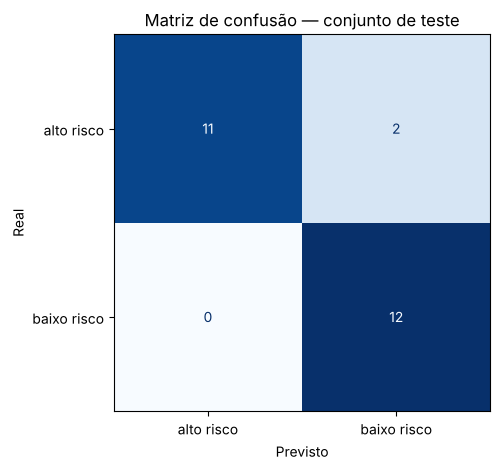

Alto risco classificado como baixo (erro mais grave): 2


In [5]:
classes = list(modelo.classes_)
matriz = confusion_matrix(rotulos_teste, previsoes, labels=classes)
ConfusionMatrixDisplay(matriz, display_labels=classes).plot(cmap="Blues", colorbar=False)
plt.title("Matriz de confusão — conjunto de teste")
plt.xlabel("Previsto"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

# O erro mais grave em triagem: paciente de alto risco classificado como baixo
falsos_negativos = matriz[classes.index("alto risco"), classes.index("baixo risco")]
print(f"Alto risco classificado como baixo (erro mais grave): {falsos_negativos}")

## 4. A acurácia é estável? Validação cruzada

Com poucas frases, um único corte treino/teste depende muito da sorte do sorteio. A validação
cruzada em 5 partes repete o treino 5 vezes e mostra a variação. Também comparamos com outros
dois modelos simples.

In [6]:
validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
candidatos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=SEMENTE),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=SEMENTE),
    "Naive Bayes": MultinomialNB(),
}
linhas = []
for nome, classificador in candidatos.items():
    acuracias = cross_val_score(make_pipeline(criar_vetorizador(), classificador),
                                frases["frase"], frases["situacao"], cv=validacao)
    linhas.append({"modelo": nome, "acurácia média": acuracias.mean(),
                   "desvio": acuracias.std(), "mínimo": acuracias.min(), "máximo": acuracias.max()})
comparacao = pd.DataFrame(linhas).set_index("modelo").round(3)
comparacao

,acurácia média,desvio,mínimo,máximo
modelo,,,,
Regressão Logística,0.89,0.058,0.80,0.95
Árvore de Decisão,0.81,0.058,0.70,0.85
Naive Bayes,0.89,0.020,0.85,0.90


## 5. O que o modelo aprendeu?

Os coeficientes da Regressão Logística mostram quais termos puxam para cada classe.

In [7]:
termos = modelo[0].get_feature_names_out()
# coef_ positivo aponta para classes_[1]; negativo, para classes_[0]
coeficientes = pd.Series(modelo[-1].coef_[0], index=termos).sort_values()
print(f"Termos que mais puxam para '{classes[0]}':")
print(coeficientes.head(12).round(2).to_string())
print(f"\nTermos que mais puxam para '{classes[1]}':")
print(coeficientes.tail(12)[::-1].round(2).to_string())

Termos que mais puxam para 'alto risco':
peito        -0.80
no peito     -0.72
ar           -0.55
de ar        -0.51
falta        -0.51
falta de     -0.51
de repente   -0.42
repente      -0.42
dor no       -0.35
que          -0.33
desmaiei     -0.32
frio         -0.30

Termos que mais puxam para 'baixo risco':
depois       0.65
leve         0.62
um pouco     0.53
pouco        0.53
depois de    0.48
pouco de     0.41
um           0.37
do           0.34
nas          0.32
tive         0.31
so           0.29
depois do    0.28


In [8]:
resultado_teste = pd.DataFrame({"frase": frases_teste, "real": rotulos_teste, "previsto": previsoes})
resultado_teste["prob_alto_risco"] = modelo.predict_proba(frases_teste)[:, classes.index("alto risco")].round(2)
erros = resultado_teste[resultado_teste["real"] != resultado_teste["previsto"]]
print(f"Erros no teste: {len(erros)} de {len(resultado_teste)}")
pd.set_option("display.max_colwidth", None)
erros

Erros no teste: 2 de 25


,frase,real,previsto,prob_alto_risco
7,meu coração disparou do nada e fiquei com a visão escura,alto risco,baixo risco,0.48
10,de repente fiquei com a fala enrolada e fraqueza em um lado do corpo,alto risco,baixo risco,0.50


## 6. Padrões, distorções e vieses: testes de estresse

A acurácia acima mede o modelo em frases **parecidas com as do treino**. Para ver como ele se
comporta fora dessa zona de conforto, escrevemos frases novas em quatro grupos, cada um testando
uma distorção previsível de um modelo de "saco de palavras":

| Grupo | O que testa | Rótulo esperado |
|---|---|---|
| Negação | O paciente **nega** sintomas graves | baixo risco |
| Atenuadores | Sintoma grave descrito com "leve", "um pouco" | alto risco |
| Linguagem coloquial | Sintoma grave em fala informal/regional | alto risco |
| Apresentação atípica | Infarto sem dor no peito clássica (mais comum em mulheres, idosos e diabéticos) | alto risco |

O último grupo retoma o **viés de sexo** documentado na Fase 1 (base UCI com 68 % de homens).

In [9]:
testes_estresse = {
    "Negação": ("baixo risco", [
        "não tenho dor no peito nem falta de ar",
        "não sinto aperto no peito",
        "nunca desmaiei e não tenho palpitações",
        "sem dor no peito e sem suor frio",
        "a falta de ar passou e não voltou",
    ]),
    "Atenuadores": ("alto risco", [
        "tenho um pouco de dor no peito e um leve suor frio",
        "é só um leve aperto no peito que vai para o braço",
        "desmaiei um pouco hoje, mas já passou",
        "sinto uma leve dormência no rosto e a fala um pouco enrolada",
        "estou com um pouco de falta de ar mesmo parado",
    ]),
    "Linguagem coloquial": ("alto risco", [
        "tô com uma batedeira no peito e a vista escurecendo",
        "deu um troço ruim no peito e fiquei todo molhado de suor",
        "parece que tem um elefante sentado em cima de mim",
        "fiquei com a boca caída e não falo coisa com coisa",
        "tô sem fôlego nenhum, nem consigo falar",
    ]),
    "Apresentação atípica": ("alto risco", [
        "estou com muito cansaço, enjoo e dor nas costas desde ontem",
        "sinto um mal-estar estranho, náusea e dor na mandíbula",
        "tenho indigestão forte e um cansaço fora do normal há horas",
        "sinto dor entre as escápulas e muita fraqueza",
        "estou com uma ansiedade repentina, falta de fôlego e enjoo",
    ]),
}

linhas = []
for grupo, (esperado, lista_frases) in testes_estresse.items():
    probabilidades = modelo.predict_proba(lista_frases)[:, classes.index("alto risco")]
    for frase, previsto, prob in zip(lista_frases, modelo.predict(lista_frases), probabilidades):
        linhas.append({"grupo": grupo, "frase": frase, "esperado": esperado,
                       "previsto": previsto, "prob_alto_risco": round(prob, 2),
                       "acertou": previsto == esperado})
estresse = pd.DataFrame(linhas)
estresse

,grupo,frase,esperado,previsto,prob_alto_risco,acertou
0,Negação,não tenho dor no peito nem falta de ar,baixo risco,alto risco,0.70,False
1,Negação,não sinto aperto no peito,baixo risco,alto risco,0.57,False
2,Negação,nunca desmaiei e não tenho palpitações,baixo risco,alto risco,0.51,False
3,Negação,sem dor no peito e sem suor frio,baixo risco,alto risco,0.60,False
4,Negação,a falta de ar passou e não voltou,baixo risco,alto risco,0.56,False
5,Atenuadores,tenho um pouco de dor no peito e um leve suor frio,alto risco,baixo risco,0.45,False
6,Atenuadores,é só um leve aperto no peito que vai para o braço,alto risco,alto risco,0.54,True
7,Atenuadores,"desmaiei um pouco hoje, mas já passou",alto risco,baixo risco,0.41,False
8,Atenuadores,sinto uma leve dormência no rosto e a fala um pouco enrolada,alto risco,baixo risco,0.38,False
9,Atenuadores,estou com um pouco de falta de ar mesmo parado,alto risco,alto risco,0.51,True


In [10]:
resumo = estresse.groupby("grupo", sort=False)["acertou"].agg(acertos="sum", total="count")
resumo["taxa de acerto"] = (resumo["acertos"] / resumo["total"]).map("{:.0%}".format)
print(f"Acurácia no teste original: {accuracy_score(rotulos_teste, previsoes):.0%}")
print(f"Acurácia nos testes de estresse: {estresse['acertou'].mean():.0%}\n")
resumo

Acurácia no teste original: 92%
Acurácia nos testes de estresse: 35%



,acertos,total,taxa de acerto
grupo,,,
Negação,0,5,0%
Atenuadores,2,5,40%
Linguagem coloquial,3,5,60%
Apresentação atípica,2,5,40%


## 7. Conclusões

**Desempenho.** O modelo acertou **92 % do teste (23 de 25 frases)**. Na validação cruzada a
Regressão Logística ficou em **89 % ± 6 %** (de 80 % a 95 % conforme o corte), empatada na média
com o Naive Bayes e acima da Árvore de Decisão (81 %). A variação entre cortes mostra que, com
100 frases, um número único de acurácia não deve ser lido com precisão de casa decimal.

**Os erros não são simétricos.** Os 2 erros do teste foram **alto risco classificado como baixo**,
o erro mais perigoso em triagem. As duas frases (coração disparado com visão escura; fala enrolada
com fraqueza em um lado do corpo) descrevem quadros graves **sem** as palavras "peito" e
"falta de ar", e ficaram com probabilidade de 0,48 e 0,50, praticamente em cima do limiar.

**O que o modelo realmente aprendeu.** Os coeficientes mostram que ele decide por poucos termos:
"peito", "falta de ar" e "de repente" puxam para alto risco; "leve", "um pouco" e "depois de"
puxam para baixo risco. Isso é um **atalho lexical**: o modelo reconhece o vocabulário das nossas
frases, não a gravidade clínica.

**Distorções confirmadas nos testes de estresse (35 % de acerto, 7 de 20):**

| Grupo | Acerto | Leitura |
|---|---|---|
| Negação | 0 de 5 | "Não tenho dor no peito" é lida como dor no peito. O TF-IDF conta palavras e ignora a ordem e o "não". |
| Atenuadores | 2 de 5 | "Leve" e "um pouco" reduzem o risco mesmo junto de desmaio ou fala enrolada. Paciente que minimiza o sintoma é subtriado. |
| Linguagem coloquial | 3 de 5 | Acerta quando a frase ainda contém "peito"; erra com metáforas e termos fora do vocabulário de treino. |
| Apresentação atípica | 2 de 5 | Cansaço, enjoo e dor nas costas ou na mandíbula, sem dor no peito, tendem a baixo risco. |

**Por que isso é viés, e não só erro.** O último grupo descreve a apresentação de infarto mais
frequente em **mulheres, idosos e diabéticos**. Um triador que depende da "dor no peito" clássica
erra sistematicamente contra esses grupos, o mesmo mecanismo do viés de sexo que documentamos na
base UCI na Fase 1. O grupo de linguagem coloquial aponta um viés semelhante de **escolaridade e
região**: quem descreve o sintoma fora do registro "de consultório" é pior atendido.
A origem está nos dados: as 100 frases foram escritas por uma única pessoa, em um único registro
de linguagem, e os rótulos não foram validados por profissional de saúde.

**O que faríamos antes de qualquer uso real:**
1. Ampliar e diversificar a base (negações, linguagem coloquial, apresentações atípicas), com
   rótulos revisados por profissional de saúde.
2. Tratar negação antes da vetorização, como o extrator por regras da Parte 1 já faz.
3. Baixar o limiar de decisão para privilegiar a sensibilidade em "alto risco": em triagem, um
   falso alarme custa menos do que um caso grave liberado.
4. Reportar o desempenho por subgrupo, e não só a acurácia agregada (compromisso 7.3 da Fase 1).
5. Manter o modelo como apoio à priorização, com decisão final humana.